# Step 1: Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

streaming = pd.read_csv('streaming_catalog.csv')

In [ ]:
plt.rcParams.update({
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'grid.color': '#222222',
    'font.family': 'sans-serif',
    'text.color': 'white',

    'axes.titlecolor'   : '#fff',
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'center',
    'axes.titlepad': 14,
    'axes.titlesize'    : 14,

    'axes.labelsize'    : 10,
    'axes.labelcolor'   : '#fff',

    'xtick.color'       : '#aaa',
    'ytick.color'       : '#aaa',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

In [ ]:
#for categorizing platforms
platform_palette = {
    'Netflix': '#E50914',
    'Amazon Prime Video': '#00A8E1',
    'Disney+': '#113CCF',
    'Hulu': '#1CE783',
    'HBO Max': '#FF5733',
    'Paramount+': '#800080',
    'Apple TV+': '#FFFFFF',
    'Peacock': '#FFFF00',
    'JioCinema': '#FFB6C1',
    'Crunchyroll': '#B3E0DC'
}

#for categorize content quality
quality_palette = ['#F44336', '#6A5ACD', '#FFC700', '#4CAF50']

# Step 2: Data overview

In [ ]:
print("Streaming info:")
print(streaming.info())

print("Streaming statistics:")
print(streaming.describe())

Streaming info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   show_id                15000 non-null  object 
 1   title                  15000 non-null  object 
 2   type                   15000 non-null  object 
 3   platform               15000 non-null  object 
 4   primary_genre          15000 non-null  object 
 5   genres                 15000 non-null  object 
 6   director               9924 non-null   object 
 7   cast                   15000 non-null  object 
 8   country                15000 non-null  object 
 9   language               15000 non-null  object 
 10  release_year           15000 non-null  int64  
 11  date_added             15000 non-null  object 
 12  rating                 15000 non-null  object 
 13  duration               15000 non-null  object 
 14  duration_minutes       8704 non-null  

# Step 3: Preprocessing

## Check for missing values

In [ ]:
missing_data = streaming.isnull().sum()
total_rows = len(streaming)
missing_percentage = (missing_data / total_rows) * 100

summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage (%)': missing_percentage.round(2)
})

missing_report = summary[summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_report

,Missing Count,Percentage (%)
num_seasons,8704,58.03
num_episodes,8704,58.03
duration_minutes,6296,41.97
budget_million_usd,6296,41.97
director,5076,33.84


## Handle missing values

In [ ]:
streaming['num_seasons'] = streaming['num_seasons'].fillna(0)
streaming['num_episodes'] = streaming['num_episodes'].fillna(0)

streaming['director'] = streaming['director'].fillna('Unknown')

streaming['duration_minutes'] = streaming['duration_minutes'].fillna(streaming['duration_minutes'].mean())
streaming['budget_million_usd'] = streaming['budget_million_usd'].fillna(0)

## Categorize content quality

In [ ]:
bins = [0, 5, 7, 8.5, 10]
labels = ['Flop (<5)', 'Average (5-7)', 'Good (7-8.5)', 'Masterpiece (>8.5)']

# Step 4: Market Overview


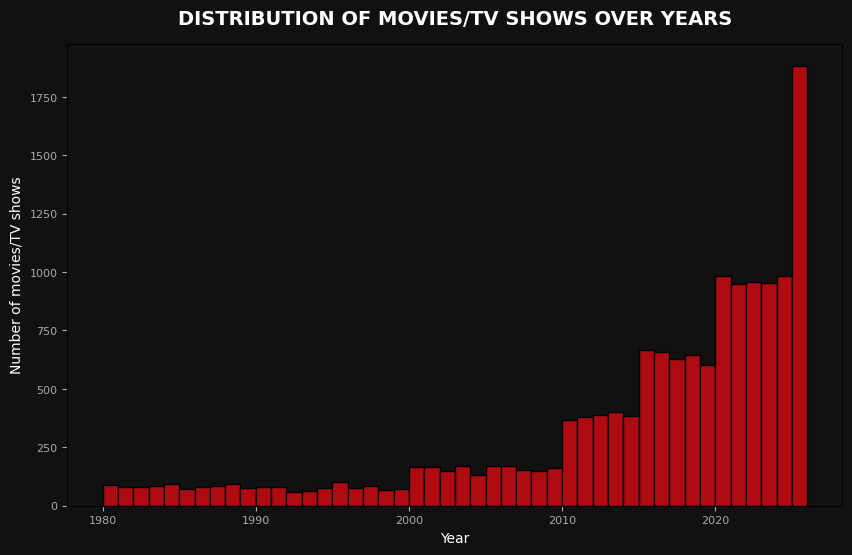

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(streaming['release_year'], bins=46, color='#E50914')
plt.title('DISTRIBUTION OF MOVIES/TV SHOWS OVER YEARS')
plt.xlabel('Year')
plt.ylabel('Number of movies/TV shows')
plt.show()

Low phase (1980 - 2010): The volume of content is very low and stays flat. This represents the era when traditional TV and cinema dominated the market.

The first leap forward (2011 - 2015): Content production starts to grow significantly. By 2015, the annual volume passed 350 titles for the first time. This reflects the expansion of high-speed internet and the early growth of major platforms like Netflix.

Explosive phase (2015 - 2024): Content production spikes and maintains a high, stable level at around 1,000 titles per year. The stability from 2021 to 2024 shows that the streaming industry has achieved industrialized, mass-scale production.

Peak in 2026: The data shows a massive record high of nearly 2,000 titles in 2026. This sharp increase proves that platforms are aggressively refreshing their libraries to compete for user attention.

=> Since the data is heavily skewed towards the most recent years (2022-2026), we will filter and focus on this recent 5-year period for the next steps of our analysis to get the most relevant market insights.

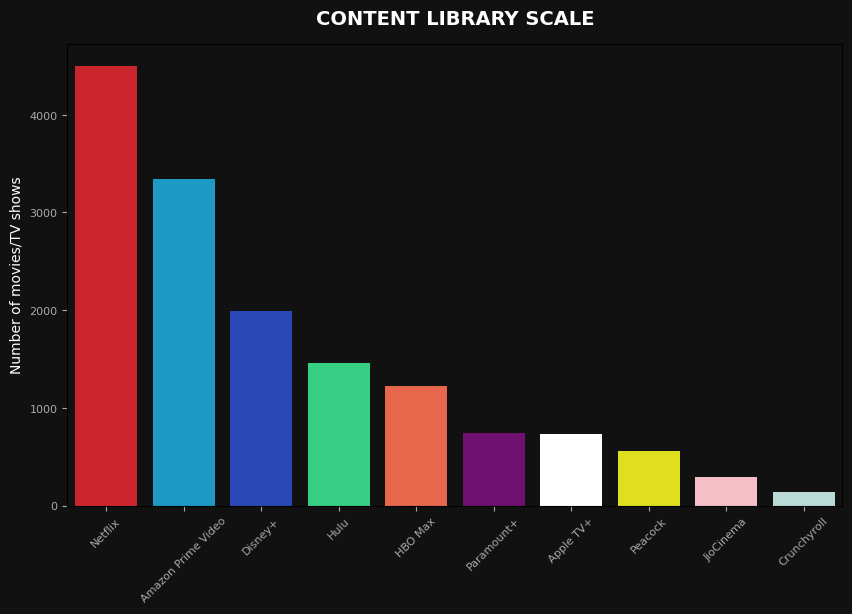

In [ ]:
platform_size = streaming['platform'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=platform_size.index,
    y=platform_size.values,
    palette=platform_palette,
    legend=False,
    hue=platform_size.index)
plt.title('CONTENT LIBRARY SCALE')
plt.ylabel('Number of movies/TV shows')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

The data reveals a massive gap in library sizes among streaming services. Netflix holds the absolute crown as the industry giant with a library exceeding 4500 titles. Following at a distant second is Amazon Prime Video, managing a highly substantial database of over 3000 titles.

=> Netflix is clearly pursuing a "mass market" strategy.

=> While library volume tells a story of financial scale and market reach, it does not reflect user satisfaction. To evaluate if a larger library correlates with better reception, we need to compare these volumes against the average user ratings in the next step.

# Step 5: Performance Analysis

In [ ]:
streaming_5_years = streaming[streaming['release_year'] >= 2022].copy()

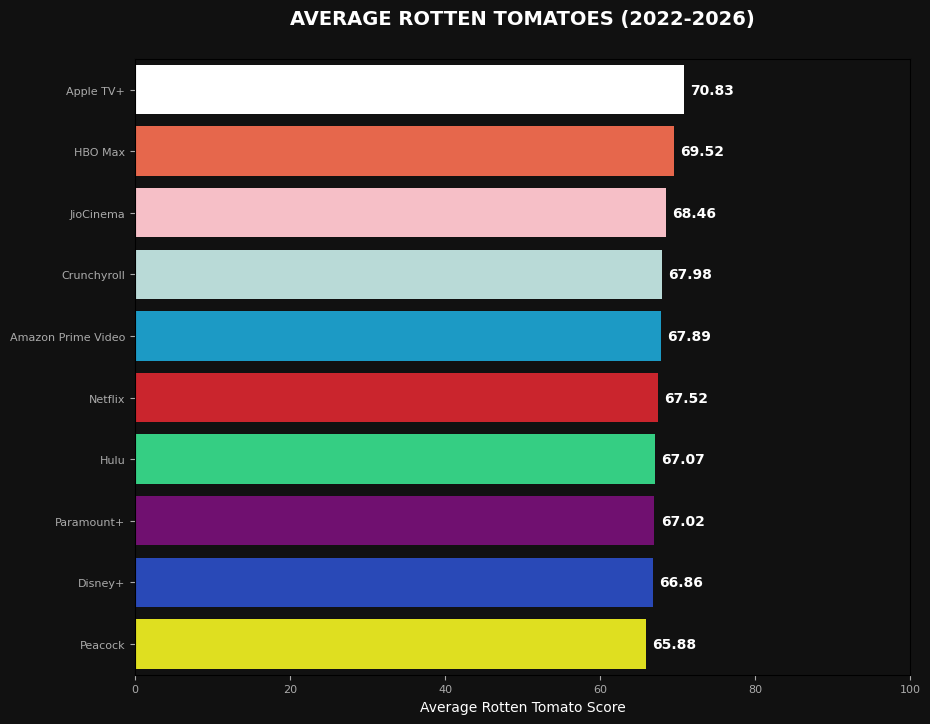

In [ ]:
platform_tomatoes_avg = streaming_5_years.groupby('platform')['rotten_tomatoes_score'].mean().reset_index()

platform_tomatoes_avg = platform_tomatoes_avg.sort_values('rotten_tomatoes_score', ascending=False)

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=platform_tomatoes_avg,
    x='rotten_tomatoes_score',
    y='platform',
    palette=platform_palette,
    hue='platform')

for i, v in enumerate(platform_tomatoes_avg['rotten_tomatoes_score']):
    ax.text(v + 0.8, i, f'{v:.2f}', color='white', va='center', fontweight='bold')

plt.title('AVERAGE ROTTEN TOMATOES (2022-2026)', pad=25)
plt.xlabel('Average Rotten Tomato Score')
plt.ylabel('')
plt.xlim(0, 100)
plt.show()

Apple TV+ leads the industry with the highest average score of 70.83, closely followed by HBO Max at 69.52. This validates that platforms with smaller library volumes (as seen in the previous step) achieve higher critical acclaim.

Giant platforms like Amazon Prime Video (67.89) and Netflix (67.52) manage to maintain solid, competitive average scores above the 67-point threshold. Maintaining a stable average while handling a massive volume of annual releases demonstrates highly resilient quality control workflows.

While critical scores from Rotten Tomatoes reflect expert opinions, they do not always align with general audience engagement. We will analyze the average IMDb ratings to evaluate user satisfaction and see if the public shares the same preferences as the critics.

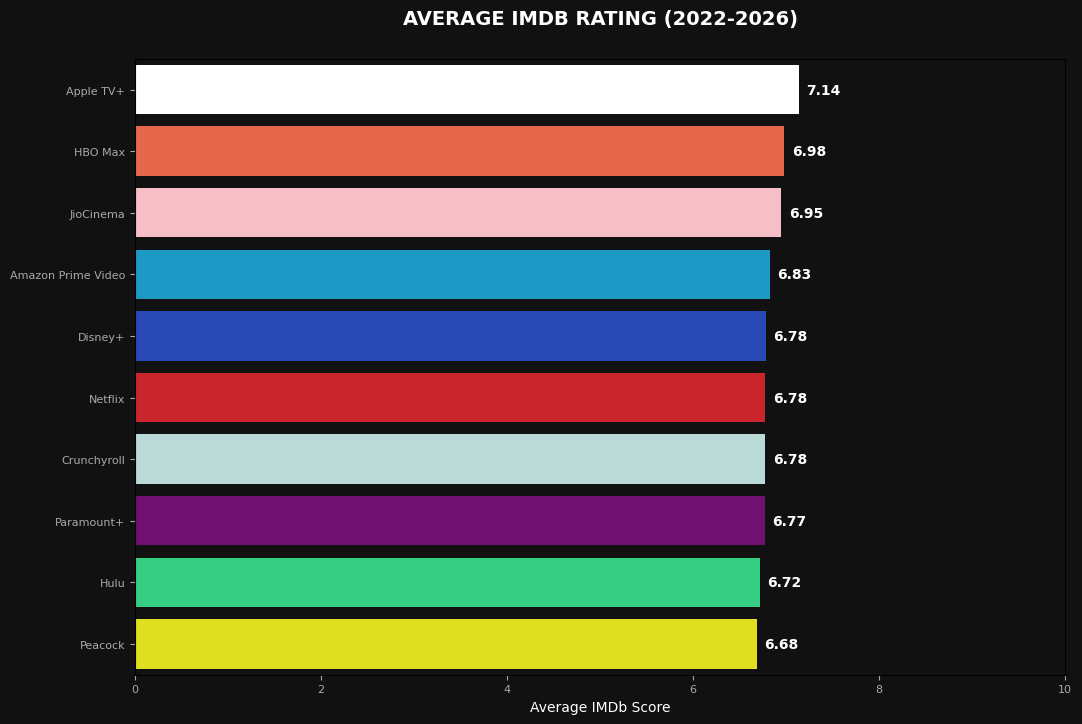

In [ ]:
platform_imdb_avg = streaming_5_years.groupby('platform')['imdb_rating'].mean().reset_index()

platform_imdb_avg = platform_imdb_avg.sort_values('imdb_rating', ascending=False)

plt.figure(figsize=(12, 8))

ay = sns.barplot(
    data=platform_imdb_avg,
    x='imdb_rating',
    y='platform',
    palette=platform_palette,
    hue='platform'
)

for i, v in enumerate(platform_imdb_avg['imdb_rating']):
    ay.text(v + 0.08, i, f'{v:.2f}', color='white', va='center', fontweight='bold')

plt.title('AVERAGE IMDB RATING (2022-2026)', pad=25)
plt.xlabel('Average IMDb Score')
plt.ylabel('')
plt.xlim(0, 10)
plt.show()

Apple TV+ maintains its top position as the only streaming platform to clear the 7-point threshold, scoring 7.14, with HBO Max closely following at 6.98. Looking back at the Rotten Tomatoes chart, this confirms that both platforms successfully satisfy both professional critics and general audiences through highly selective curation.

Major industry giants including Amazon Prime Video (6.83), Disney+ (6.78), and Netflix (6.78) see their scores clustered tightly in the average tier. These platforms manage massive library scales to cater to hundreds of millions of global users so their highly varied content scores naturally regress toward a stable industry mean.

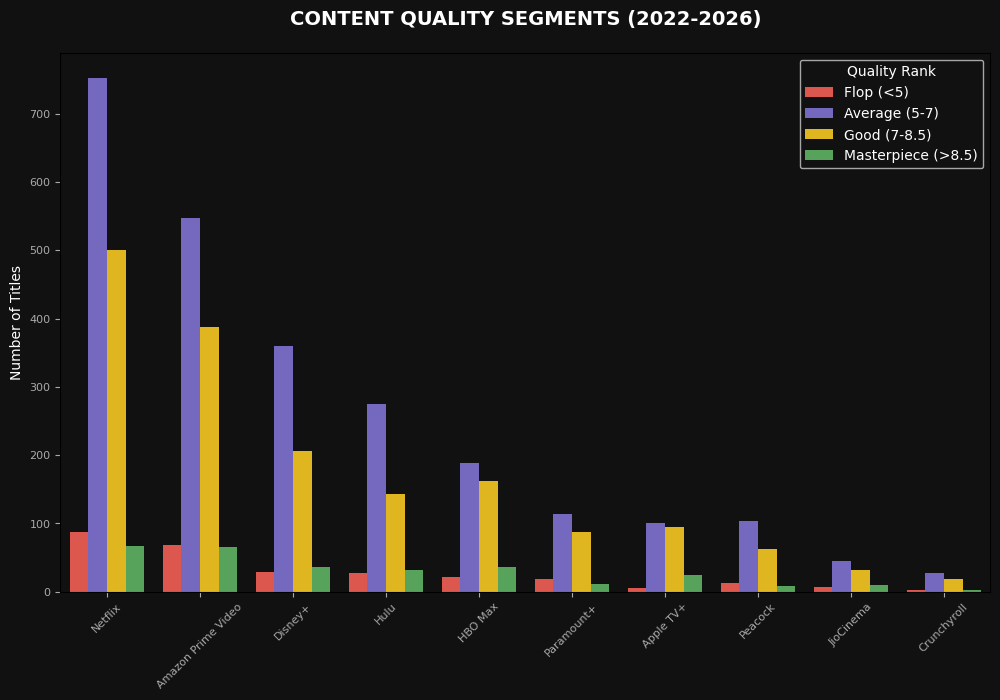

In [ ]:
streaming_5_years['score_group'] = pd.cut(streaming_5_years['imdb_rating'], bins=bins, labels=labels)

plt.figure(figsize=(12, 7))
sns.countplot(
    data=streaming_5_years,
    x='platform',
    hue='score_group',
    palette=quality_palette,
    order=streaming_5_years['platform'].value_counts().index
)

plt.title('CONTENT QUALITY SEGMENTS (2022-2026)', pad=20)
plt.ylabel('Number of Titles')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Quality Rank', loc='upper right')
plt.show()

Netflix and Amazon Prime Video lead the industry in absolute volume across almost all categories. They possess the highest number of Masterpiece titles (ratings above 8.5). However, due to their industrial scale, they also record the highest number of Flop titles (ratings below 5) in the market. This distribution shows a strategic trade-off where platforms accept a higher volume of low-performing content to maximize their chances of producing global hits.

Apple TV+ demonstrates an entirely different distribution shape. Its Flop segment is nearly invisible on the chart. More importantly, the volume of its Good segment (ratings 7-8.5) is almost equal to its Average segment (ratings 5-7). This highly balanced distribution with zero downside risk explains why Apple TV+ achieves the highest average IMDb score of 7.14.

In the final step, we will visualize total industry recognition by looking at the total number of major awards won by each platform over the last 5 years.

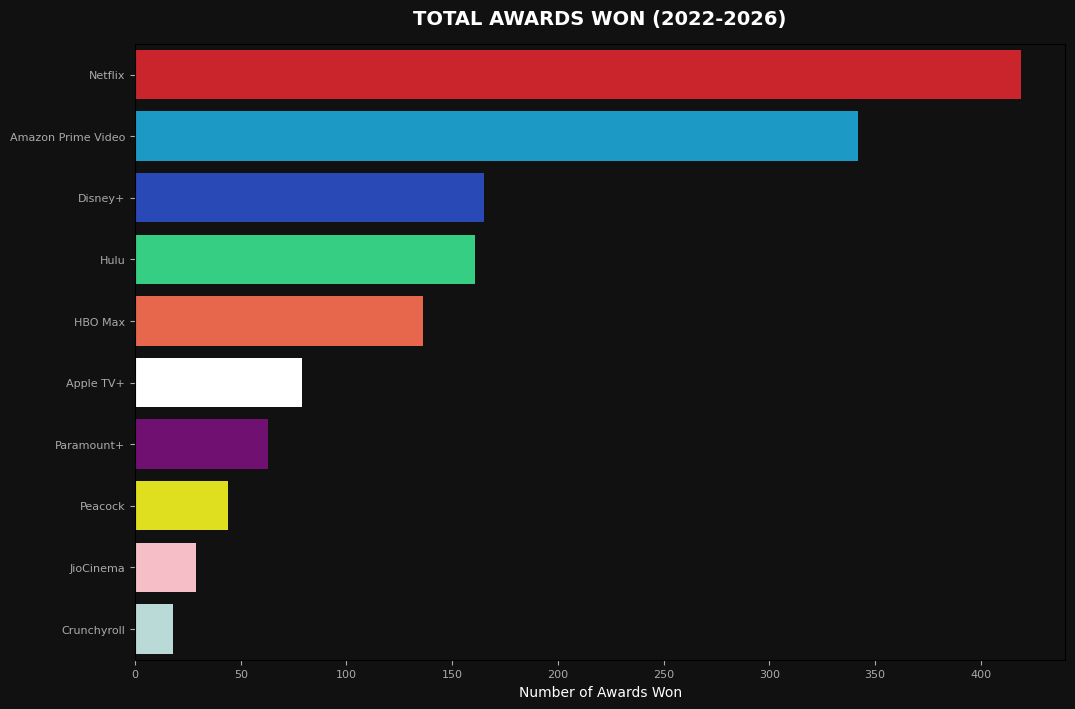

In [ ]:
number_awards = streaming_5_years.groupby('platform')['awards_won'].sum().sort_values(ascending=False)
awards_df = number_awards.reset_index(name='total_awards')

plt.figure(figsize=(12, 8))

az = sns.barplot(
    data=awards_df,
    x='total_awards',
    y='platform',
    palette=platform_palette,
    hue='platform'
)

plt.title('TOTAL AWARDS WON (2022-2026)')
plt.xlabel('Number of Awards Won')
plt.ylabel('')
plt.show()

Netflix holds the absolute lead with the most number of awards won, followed closely by Amazon Prime Video. When cross-examined with the previous metrics, this observation provides a vital context. Although Netflix maintains a standard average score of 6.78 due to its vast, mass-market catalog, its top-tier content successfully dominates the competitive landscape.

Platforms like Apple TV+ and HBO Max rely on a selective, premium model to secure high user satisfaction and critic ratings. Conversely, giants like Netflix and Amazon Prime Video leverage substantial financial scale to deploy a multi-tiered catalog, successfully capturing both mass-market watch time and top-tier industry awards.

In the final step, we will visualize total industry recognition by looking at the total number of major awards won by each platform over the last 5 years.

# Step 6: Strategic Positioning

In [ ]:
streaming_2026 = streaming[streaming['release_year'] == 2026].copy()

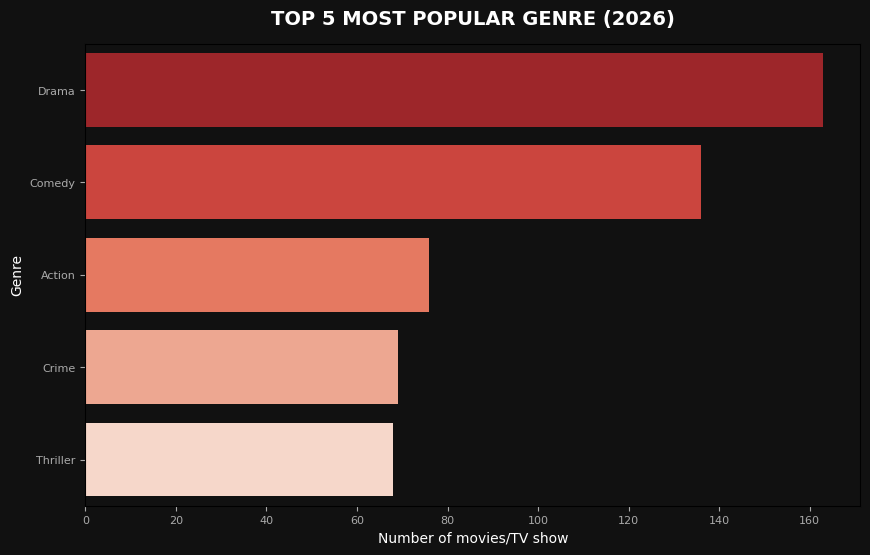

In [ ]:
top_genre_2026 = streaming_2026['primary_genre'].value_counts().head(5)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genre_2026.values,
    y=top_genre_2026.index,
    hue=top_genre_2026.index,
    palette='Reds_r')

plt.title('TOP 5 MOST POPULAR GENRE (2026)')
plt.xlabel('Number of movies/TV show')
plt.ylabel('Genre')
plt.show()

Drama holds the undisputed top position with over 160 releases in 2026, followed by Comedy at over 130 titles. This extreme concentration shows where streaming services focus the absolute majority of their budget and creative resources, turning Drama and Comedy into the primary competitive landscape for user acquisition.

Action, Crime, and Thriller form a balanced secondary tier, with each genre stabilizing around 70 to 80 titles.

The significant volume gap between the top two genres and the rest of the list highlights a highly focused content development strategy across the industry. Platforms prioritize high-volume, emotionally engaging categories to maximize mass-market appeal.

While total volume proves that Drama is the most heavily produced genre of 2026, it does not tell us which platforms actually win the quality race within these popular categories. Therefore, we will get a deeper insight into the scale of drama genre of each platform.

In [ ]:
drama_2026 = streaming_2026[streaming_2026['primary_genre'].str.contains('Drama')].copy()

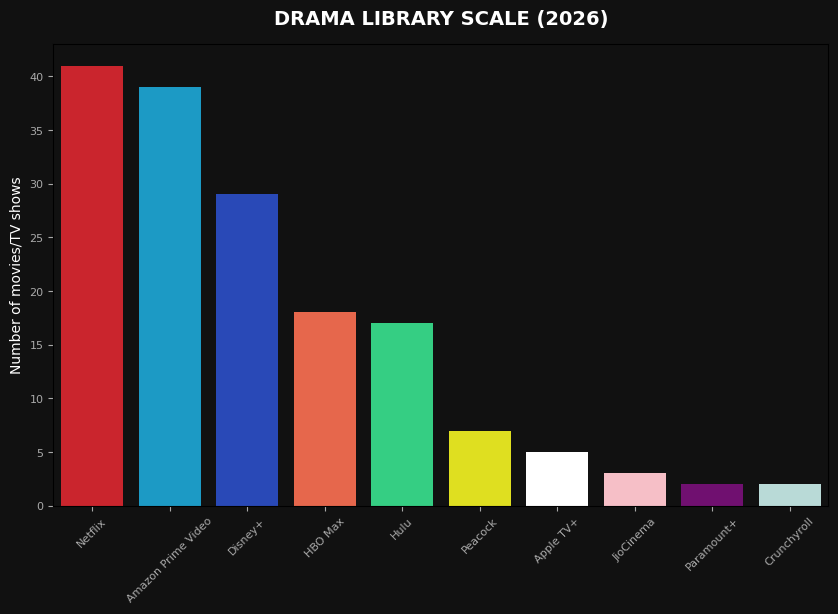

In [ ]:
platform_drama_size = drama_2026['platform'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=platform_drama_size.index,
    y=platform_drama_size.values,
    palette=platform_palette,
    legend=False,
    hue=platform_drama_size.index)

plt.title('DRAMA LIBRARY SCALE (2026)')
plt.ylabel('Number of movies/TV shows')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

Netflix and Amazon Prime Video continue to command the market. This tight gap shows that both giants are directly matching each other's investments in the Drama category to capture the largest possible share of core audience watch time.

Disney+ establishes a firm third position with 29 titles, setting a clear gap ahead of HBO Max and Hulu. On the lower end of the scale, niche or specialized platforms like Paramount+ and Crunchyroll contribute a minimal 2 titles each, indicating that they do not use the heavy drama space as their primary customer acquisition tool.

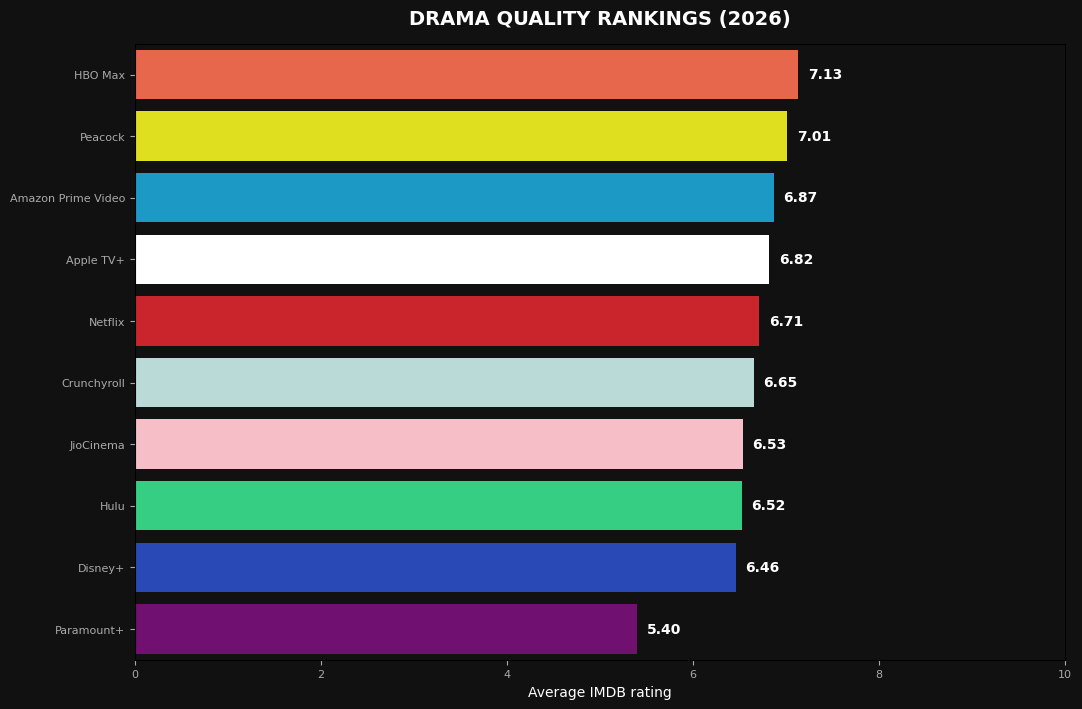

In [ ]:
avg_drama_rating = drama_2026.groupby('platform')['imdb_rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=avg_drama_rating.values,
    y=avg_drama_rating.index,
    palette=platform_palette,
    legend=False,
    hue=avg_drama_rating.index)

for i, v in enumerate(avg_drama_rating.values):
    ax.text(v + 0.1, i, f'{v:.2f}', color='white', va='center', fontweight='bold')

plt.xlim(0, 10)

plt.title('DRAMA QUALITY RANKINGS (2026)')
plt.xlabel('Average IMDB rating')
plt.ylabel('')
plt.show()

HBO Max takes the top position with an average IMDb score of 7.13, followed closely by Peacock at 7.01. This observation highlights a highly effective genre specialization strategy. Even though HBO Max does not hold the largest volume of drama shows (as seen in the library scale chart), its focus on premium quality execution allows it to secure the highest audience satisfaction in this critical category.

The industry giants, Amazon Prime Video (6.87) and Netflix (6.71), position themselves firmly in the upper-middle tier. Given their massive annual release volumes, maintaining a stable rating close to or above the 6.8 mark proves that their large-scale production workflows can still deliver solid and respectable content performance. Meanwhile, Disney+ sits lower at 6.46, suggesting that its expansive catalog faces a slight quality dilution within the drama category.

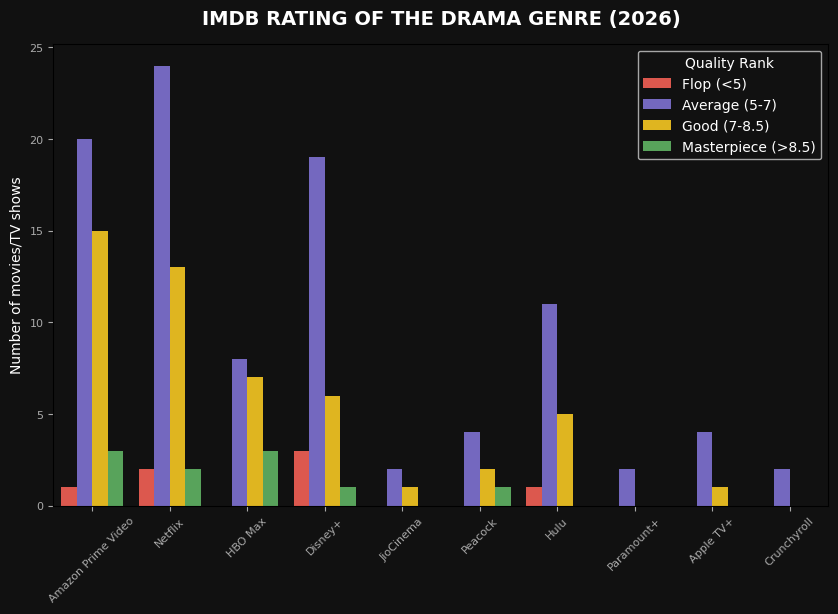

In [ ]:
drama_2026['score_group'] = pd.cut(
    drama_2026['imdb_rating'],
    bins=bins,
    labels=labels)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=drama_2026,
    x='platform',
    hue='score_group',
    palette=quality_palette,
)

plt.title('IMDB RATING OF THE DRAMA GENRE (2026)')
plt.ylabel('Number of movies/TV shows')
plt.legend(title='Quality Rank')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

HBO Max leads the genre with a top average rating of 7.13. Its quality distribution shows zero Flops alongside an impressively thick ratio of Good and Masterpiece titles relative to its smaller size. Similarly, Apple TV+ showcases elite product control with its 5 drama releases, distributing tightly into 4 Average and 1 Good titles with zero Flop presence, maintaining its high-end brand identity at 6.82.

In the battle of the mass-market scale leaders, Amazon Prime Video establishes a noticeable quality lead over Netflix. Amazon Prime achieves a 6.87 average rating compared to Netflix's 6.71, supported by a stronger distribution of Good and Masterpiece titles.

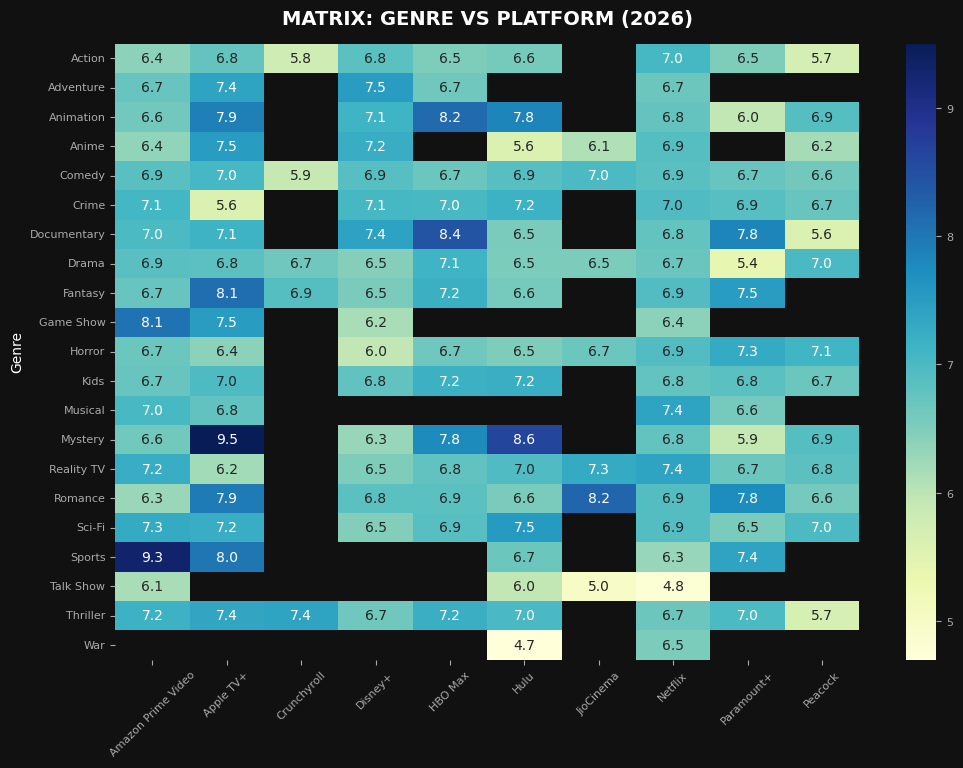

In [ ]:
pivot_table = streaming_2026.pivot_table(
    index='primary_genre',
    columns='platform',
    values='imdb_rating',
    aggfunc='mean')

plt.figure(figsize=(12, 8))

sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('MATRIX: GENRE VS PLATFORM (2026)')
plt.ylabel('Genre')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

Netflix demonstrates a near-perfect vertical density across the matrix, leaving virtually no black slots unfulfilled. This structural pattern validates a global entertainment supermarket strategy where data coverage takes priority over premium extremes. To prevent missing any market segments, the system accepts a high density of average ratings (mostly light green and teal tiles ranging from 6.5 to 7.4) rather than optimizing for peak quality.

Apple TV+ shows the opposite matrix profile, featuring multiple high-intensity dark blue blocks alongside empty black intervals. Their performance peaks drastically in the Mystery tier at 9.5, alongside exceptional marks in Animation (7.9), Fantasy (8.1), and Romance (7.9).

Amazon Prime Video covers almost every genre on its platform. It also boasts many dark blue boxes (scores ranging from Good to Masterpiece). They have achieved both mass coverage (releasing almost every genre) and maintained top-notch quality across various content areas.